# Notebook 2: Combined Model Training

**PronounceAI — Combined Module**

Trains a meta-model that learns to predict overall pronunciation quality
from the two module scores.

| Input feature | Source |
|---|---|
| `module1_score` | Word accuracy from Whisper ASR (0–100) |
| `module2_score` | Acoustic quality from RF+NN (0–100) |

| Output | Description |
|---|---|
| `combined_rf.joblib` | Random Forest meta-classifier |
| `combined_scaler.joblib` | StandardScaler for the 2-dim feature |
| `combined_net.pt` | Optional PyTorch MLP meta-classifier |
| `combined_config.json` | Metadata (feature names, threshold) |

> **Prerequisite:** Run `notebook1_combined_feature_generation.ipynb` first.

## Step 1: Imports and Paths

In [15]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

MODELS_DIR = Path('../models')
FEAT_CSV   = MODELS_DIR / 'combined_features.csv'

assert FEAT_CSV.exists(), (
    f'Feature CSV not found at {FEAT_CSV}.\n'
    'Run notebook1_combined_feature_generation.ipynb first.'
)
print(f'Feature CSV: {FEAT_CSV}')

Feature CSV: ..\models\combined_features.csv


## Step 2: Load and Inspect Features

Loaded 1000 samples  (good=500  degraded=500)
       module1_score  module2_score   label
count        1000.00        1000.00  1000.0
mean           78.53          52.06     0.5
std            28.79          43.74     0.5
min             0.00           0.00     0.0
25%            56.74           2.25     0.0
50%            97.26          75.19     0.5
75%           100.00          95.25     1.0
max           100.00          99.11     1.0


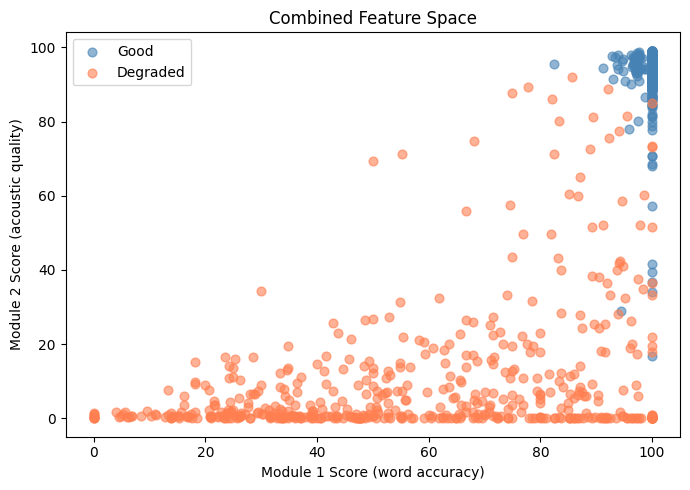

In [16]:
df = pd.read_csv(FEAT_CSV)
print(f'Loaded {len(df)} samples  (good={( df.label==1).sum()}  degraded={(df.label==0).sum()})')
print(df[['module1_score', 'module2_score', 'label']].describe().round(2))

# Scatter plot of feature space
fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(1, 'steelblue', 'Good'), (0, 'coral', 'Degraded')]:
    sub = df[df.label == label]
    ax.scatter(sub.module1_score, sub.module2_score,
               c=color, alpha=0.6, label=name, s=40)
ax.set_xlabel('Module 1 Score (word accuracy)')
ax.set_ylabel('Module 2 Score (acoustic quality)')
ax.set_title('Combined Feature Space')
ax.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / 'combined_feature_space.png', dpi=120)
plt.show()

## Step 3: Train / Test Split

In [17]:
FEATURES = ['module1_score', 'module2_score']
X = df[FEATURES].values.astype(np.float32)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train)} samples  |  Test: {len(X_test)} samples')

Train: 800 samples  |  Test: 200 samples


## Step 4: Train Random Forest (Primary Model)

In [18]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_sc, y_train)

rf_preds = rf.predict(X_test_sc)
rf_proba = rf.predict_proba(X_test_sc)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, rf_preds, target_names=['Degraded', 'Good']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

    Degraded       0.88      0.99      0.93       100
        Good       0.99      0.86      0.92       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200

ROC-AUC: 0.9877


## Step 5: Train PyTorch MLP (Optional)

Device: cpu
=== PyTorch MLP ===
              precision    recall  f1-score   support

    Degraded       0.94      0.93      0.93       100
        Good       0.93      0.94      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.93       200

ROC-AUC: 0.9872


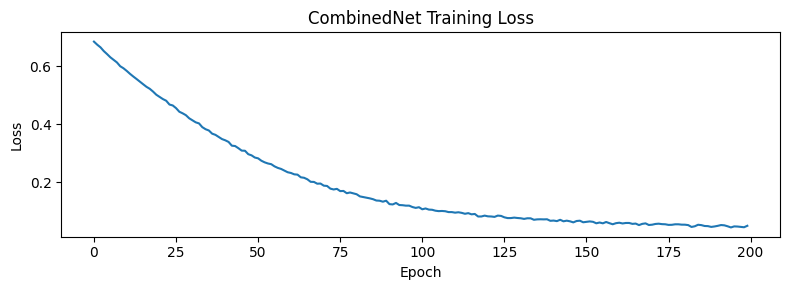

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


class CombinedNet(nn.Module):
    """Lightweight MLP meta-classifier on 2-dim input."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 2),
        )
    def forward(self, x):
        return self.net(x)


net = CombinedNet().to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

X_tr = torch.tensor(X_train_sc, dtype=torch.float32).to(device)
y_tr = torch.tensor(y_train,    dtype=torch.long).to(device)

EPOCHS = 200
losses = []
net.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    loss = criterion(net(X_tr), y_tr)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

net.eval()
with torch.no_grad():
    X_te = torch.tensor(X_test_sc, dtype=torch.float32).to(device)
    net_preds = net(X_te).argmax(dim=1).cpu().numpy()
    net_proba = torch.softmax(net(X_te), dim=1)[:, 1].cpu().numpy()

print('=== PyTorch MLP ===')
print(classification_report(y_test, net_preds, target_names=['Degraded', 'Good']))
print(f'ROC-AUC: {roc_auc_score(y_test, net_proba):.4f}')

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('CombinedNet Training Loss')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'combined_net_training_curve.png', dpi=120)
plt.show()

## Step 6: Confusion Matrices

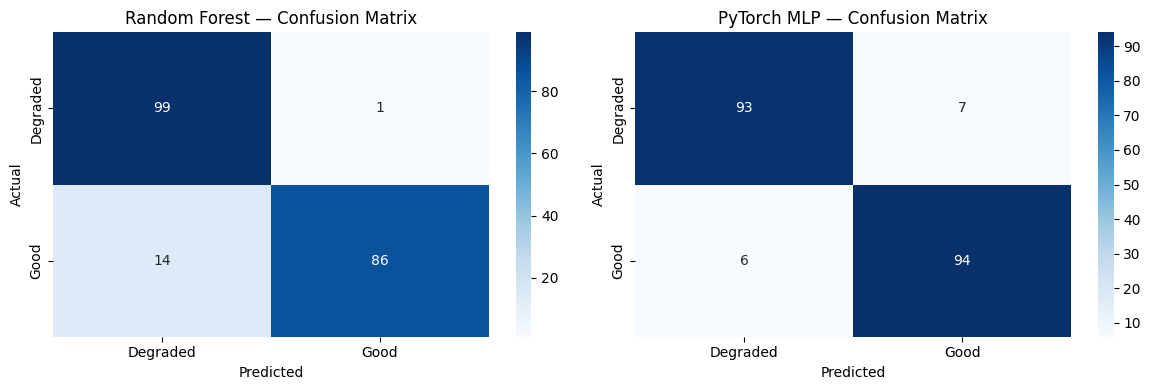

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in [
    (axes[0], rf_preds,  'Random Forest'),
    (axes[1], net_preds, 'PyTorch MLP'),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Degraded', 'Good'],
                yticklabels=['Degraded', 'Good'])
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'combined_confusion_matrices.png', dpi=120)
plt.show()

## Step 7: Save Models and Config

In [21]:
joblib.dump(rf,     MODELS_DIR / 'combined_rf.joblib')
joblib.dump(scaler, MODELS_DIR / 'combined_scaler.joblib')
torch.save(net.state_dict(), MODELS_DIR / 'combined_net.pt')

config = {
    'features':         FEATURES,
    'n_features':       len(FEATURES),
    'rf_n_estimators':  rf.n_estimators,
    'rf_max_depth':     rf.max_depth,
    'rf_accuracy':      round(accuracy_score(y_test, rf_preds), 4),
    'mlp_accuracy':     round(accuracy_score(y_test, net_preds), 4),
    'train_samples':    len(X_train),
    'test_samples':     len(X_test),
}
with open(MODELS_DIR / 'combined_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved:')
for name in ['combined_rf.joblib', 'combined_scaler.joblib',
             'combined_net.pt', 'combined_config.json']:
    p = MODELS_DIR / name
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')

Saved:
  combined_rf.joblib  (253.7 KB)
  combined_scaler.joblib  (0.6 KB)
  combined_net.pt  (5.6 KB)
  combined_config.json  (0.2 KB)
